In [1]:
import os
os.chdir('/Users/ngdnh/Codespace/PulsatingPulseShop/')
%config InlineBackend.figure_formats = ['svg']

In [2]:
import numpy as np
import utility as ut
import pickle
import datetime 
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde
import qutip as qt
from scipy.optimize import minimize

today = datetime.datetime.now()

print(f'Now is {today}')

Now is 2025-05-21 12:45:40.816504


In [3]:
my_cmap = ['#f7fcb9', '#addd8e', '#31a354']
parula_discrete = ['#3e27a9', '#0433FF', 
'#10bfbb',
'#c8c229', 
'#fafc15',]

plt.rcParams['axes.linewidth'] = 1.5

my_discrete = [
    "#2A7B7F",  # Teal
    "#F3C746",  # Yellow
    "#8DC361",  # Light Green
    "#7F3D9E",  # Purple
    "#4DA676",  # Dark Green
    "#3455A0"   # Blue
]

### Helper functions

In [4]:
def Lx01():
    return qt.Qobj(np.array([
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]
    ]))

def Lz01():
    return qt.Qobj(np.array([
        [1, 0, 0],
        [0, -1, 0],
        [0, 0, 0]
    ]))

def Lx12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 0, 1],
        [0, 1, 0]
    ]))

def Lz12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, -1]
    ]))

def rot_x12(a, p):
    return (-1j*((np.pi/2+a)/2)*Lx12()-1j*(p/2)*Lz12()).expm()

def R12(theta, phi):
    return qt.Qobj(np.array([
        [1, 0, 0],
        [0, np.cos(theta/2), -1j*np.exp(-1j*phi)*np.sin(theta/2)],
        [0, -1j*np.exp(+1j*phi)*np.sin(theta/2), np.cos(theta/2)]
    ]))

ket0 = qt.basis(3, 0)
ket1 = qt.basis(3, 1)
ket2 = qt.basis(3, 2)

def coherent_error_sim(rotation_angles, optimized_a, optimized_p):

    population = []

    if optimized_p == 0:
        p = 0
        for a in rotation_angles:
            for N in N_list:
                psi0 = ket1 
                psi0 = rot_x12(a, p) * psi0
                for _ in range(N):
                    psi0 = rot_x12(a, p)*rot_x12(a, p)*psi0 

                pop1 = (np.abs(ket1.dag()*psi0).norm())**2
                pop2 = (np.abs(ket2.dag()*psi0).norm())**2

                population.append([pop1, pop2])
    else: 
        for N in N_list:
            psi0 = ket1
            psi0 = rot_x12(optimized_a, optimized_p)*psi0
            for _ in range(N):
                psi0 = rot_x12(optimized_a, optimized_p)*rot_x12(optimized_a, optimized_p)*psi0

            pop1 = (np.abs(ket1.dag()*psi0))**2
            pop2 = (np.abs(ket2.dag()*psi0))**2
            population.append([pop1, pop2])

    population = np.array(population)

    return population


def objective(args):

    a, p = args
    
    pop2_sim = []

    for N in N_list:
        psi0 = ket1
        psi0 = rot_x12(a, p)*psi0
        for _ in range(N):
            psi0 = rot_x12(a, p)*rot_x12(a, p)*psi0

        pop2 = (np.abs(ket2.dag()*psi0))**2
        pop2_sim.append(pop2)

    pop2_sim = np.array(pop2_sim)
    pop_dif = np.abs(pop2_sim - pop2_exp)**2
    print(np.average(pop_dif))
    return np.average(pop_dif)

def pop_sim(a, p):
    population = []
    for N in N_list:
        psi0 = ket1
        psi0 = rot_x12(a, p)*psi0
        for _ in range(N):
            psi0 = rot_x12(a, p)*rot_x12(a, p)*psi0

        pop1 = (np.abs(ket1.dag()*psi0))**2
        pop2 = (np.abs(ket2.dag()*psi0))**2
        population.append([pop1, pop2])

    return np.array(population)

### Discriminator

In [20]:
discrim_id = 'cxsfpfswk6yg008ht4s0'
path = f"./characterization/rabi/data/{discrim_id}"
discrim_params = np.load(f"{path}/params.pkl", allow_pickle=True)
discrim_iq_data = np.array(np.load(f"{path}/iq_data.pkl", allow_pickle=True))

amplitude_sweep = np.linspace(discrim_params['infimum'], discrim_params['supremum'], discrim_params['num_points'])
real_avg_iq = [np.real(np.average(discrim_iq_data[idx])) for idx in range(discrim_params['num_points'])]

ansatz_amp = 1.5
outliers = 13

popt, yfit, pcov = ut.fit_function(amplitude_sweep[outliers:-outliers], 
                                   real_avg_iq[outliers:-outliers], 
                                   lambda x, A, T, phi, B: (A*np.cos(2*np.pi/T*x+phi)+B), 
                                   [30, ansatz_amp, 0, 0])

idx_amp_zero = np.argmin(real_avg_iq)
idx_amp_two = np.argmax(real_avg_iq)

distance_zero_two = ut.distance(real_avg_iq[idx_amp_zero], real_avg_iq[idx_amp_two])
IQdata_0_post_selected = []
IQdata_0_post_rejected = []
rejected_0_indices = []

for idx, IQpoint in enumerate(discrim_iq_data[idx_amp_zero]):
    if np.real(IQpoint) < real_avg_iq[idx_amp_zero]+distance_zero_two/2:
        IQdata_0_post_selected.append(IQpoint)
    else:
        rejected_0_indices.append(idx)
        IQdata_0_post_rejected.append(IQpoint)

IQdata_2_post_selected = []
IQdata_2_post_rejected = []
rejected_2_indices = []

for idx, IQpoint in enumerate(discrim_iq_data[idx_amp_two]):
    if np.real(IQpoint) > real_avg_iq[idx_amp_two]-distance_zero_two/2:
        IQdata_2_post_selected.append(IQpoint)
    else:
        rejected_2_indices.append(idx)
        IQdata_2_post_rejected.append(IQpoint)

x = np.linspace(-100, 100, 100)
mu0_ps, std0_ps = norm.fit(np.real(IQdata_0_post_selected))
mu2_ps, std2_ps = norm.fit(np.real(IQdata_2_post_selected))

p0_ps = norm.pdf(x, mu0_ps, std0_ps)
p2_ps = norm.pdf(x, mu2_ps, std2_ps)

cluster_0_mean = np.mean(IQdata_0_post_selected)
cluster_2_mean = np.mean(IQdata_2_post_selected)
radius_fit = ut.distance(cluster_0_mean, cluster_2_mean)/2

data = [
    (np.real(discrim_iq_data[idx_amp_zero]), 'Re(IQ)', 'Frequency', 'hist', {'color': 'red', 'alpha':0.5}, p0_ps),
    (np.real(IQdata_0_post_selected), np.imag(IQdata_0_post_selected), 'scatter', {'s': 3, 'alpha': 0.2, 'color': 'red'}),
    (np.real(discrim_iq_data[idx_amp_two]), 'Re(IQ)', 'Frequency', 'hist', {'color': 'blue', 'alpha':0.5}, p2_ps),
    (np.real(IQdata_2_post_selected), np.imag(IQdata_2_post_selected), 'scatter', {'s': 3, 'alpha': 0.2, 'color': 'blue'}),
]

In [74]:
def in_zero(point: complex):
    d = ut.distance(cluster_0_mean, point)
    if d < radius_fit:
        return True
    else:
        return False

def in_two(point: complex):
    d = ut.distance(cluster_2_mean, point)
    if d < radius_fit:
        return True
    else:
        return False
    
def discriminate(iq_data_level1):
    
    normal_points = []
    abnormal_points = []
    pop = []

    for data_point in iq_data_level1:
        abnormal_zero = []
        normal_zero = []
        normal_one = []
        abnormal_two = []
        normal_two = []
        for shot in data_point:
            if (in_zero(shot) == True):
                normal_zero.append(shot)
                continue
            if (in_two(shot) == True) or (np.imag(shot) < 39 and np.real(shot) > 0):
                normal_two.append(shot)
                continue
            else:
                if np.real(shot) < 0:
                    abnormal_zero.append(shot)
                    continue 
                if np.imag(shot) < 0:
                    abnormal_two.append(shot)
                    continue 
                else:
                    normal_one.append(shot)
        
        pop0 = (len(normal_zero)+len(abnormal_zero))/iq_data_level1.shape[1]
        pop1 = len(normal_one)/iq_data_level1.shape[1]
        pop2 = (len(normal_two)+len(abnormal_two))/iq_data_level1.shape[1]

        if np.abs(pop0+pop1+pop2 - 1.0) > 1e-14:
            print('Houston we have a problem!')
            print(pop0+pop1+pop2)
            
        pop_shot = [pop0, pop1, pop2]
        normal_points.append([normal_zero, normal_one, normal_two])
        abnormal_points.append([abnormal_zero, abnormal_two])
        pop.append(pop_shot)

    pop = np.array(pop)

    return normal_points, abnormal_points, pop

### Figure 1. Over-rotation

In [75]:
re1_id = 'cw0s2fsrxqkg008e2cag' # without drag, no scaling, amp = 0.2513636363636364
re2_id = 'cw0w06rvka8g008b997g' # with drag, no scaling, amp = 0.2513636363636364
re3_id = 'cw24b0crxqkg008e56j0' # with drag, scaled, repeat 1
re4_id = 'cw13qsqvka8g008b9vg0' # with drag, scaled, repeat 2
re5_id = 'cw0wed14v2e0008sg2gg' # with drag, scaled, repeat 2
re6_id = 'cvr07a5zrwzg008axdc0' # without drag, scaled from without drag
# re7_id = 'cwectds40e000088ayz0' # without drag, no scaling, amp = 0.25666666666666665, N0 = 41

exp_ids = [re1_id, re2_id, re3_id, re4_id, re5_id, re6_id]

paths = []

for id in exp_ids:
    paths.append(f"./calibrator/rotation/data/{id}")

re_iq_data = []
re_params = []
for path in paths:
    re_iq_data.append(np.array(np.load(f"{path}/iq_data.pkl", allow_pickle=True)))
    re_params.append(np.load(f"{path}/params.pkl", allow_pickle=True))

In [76]:
re_params

[{'backend': 'ibm_brisbane',
  'qubit': 109,
  're_job_id_string': 'cw0s2fsrxqkg008e2cag',
  'datetime': datetime.datetime(2024, 10, 5, 21, 19, 33, 995136),
  'duration': 40,
  'amp_sx12': 0.2513636363636364,
  'beta12': 0,
  'N0': 21,
  'num_shots': 5000,
  'delay_overlap': True,
  'mapping_01': True,
  'rep_delay': '0.00025',
  'extended_delay': '0.0',
  'idling_circuits': False,
  'unconditional_reset12': True},
 {'backend': 'ibm_brisbane',
  'qubit': 109,
  're_job_id_string': 'cw0w06rvka8g008b997g',
  'datetime': datetime.datetime(2024, 10, 6, 0, 39, 34, 423238),
  'duration': 40,
  'amp_sx12': 0.2513636363636364,
  'beta12': -0.41414141414141414,
  'N0': 21,
  'num_shots': 5000,
  'delay_overlap': True,
  'mapping_01': True,
  'rep_delay': '0.0005',
  'extended_delay': '0.0',
  'idling_circuits': False,
  'unconditional_reset12': True},
 {'backend': 'ibm_brisbane',
  'qubit': 109,
  're_job_id_string': 'cw24b0crxqkg008e56j0',
  'datetime': datetime.datetime(2024, 10, 7, 22, 46, 6

In [77]:
normal_points, abnormal_points, pop = discriminate(re_iq_data[0])

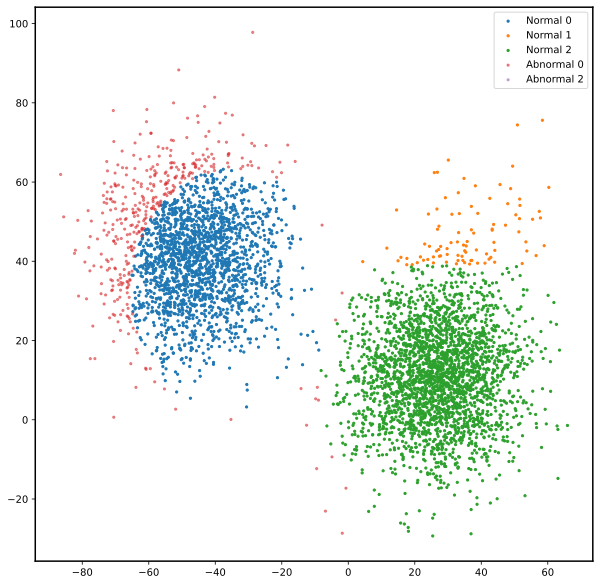

In [78]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(np.real(normal_points[0][0]), np.imag(normal_points[0][0]), s=5, label='Normal 0')
ax.scatter(np.real(normal_points[0][1]), np.imag(normal_points[0][1]), s=5, label='Normal 1')
ax.scatter(np.real(normal_points[0][2]), np.imag(normal_points[0][2]), s=5, label='Normal 2')

ax.scatter(np.real(abnormal_points[0][0]), np.imag(abnormal_points[0][0]),s=5, alpha=0.5, label='Abnormal 0')
ax.scatter(np.real(abnormal_points[0][1]), np.imag(abnormal_points[0][1]),s=5, alpha=0.5, label='Abnormal 2')

ax.legend()

In [79]:
N_list = np.array([2*n for n in range(re_params[0]['N0'])])

re_pops_2 = []
re_pops_1 = []

for iq_data in re_iq_data:
    _, _, re_pop = discriminate(iq_data)
    re_pops_1.append(re_pop[:, 0])
    re_pops_2.append(re_pop[:, 2])

In [80]:
guess_1 = [0.09, 0.15]
pop2_exp = re_pops_2[0]
sol_1 = minimize(objective, guess_1, method='Nelder-Mead', tol=1e-9)

guess_6 = [0.03, 0.15]
pop2_exp = re_pops_2[5]
sol_6 = minimize(objective, guess_6, method='Nelder-Mead', tol=1e-9)

guess_2 = [0.09, 0]
pop2_exp = re_pops_2[1]
sol_2 = minimize(objective, guess_2, method='Nelder-Mead', tol=1e-9)

# guess_3 = [0.05, 0.10]
# pop2_exp = re_pops[5]
# sol_3 = minimize(objective, guess_3, method='Nelder-Mead', tol=1e-9)

# N_list = np.array([2*n for n in range(re_params[6]['N0'])])
# guess_4 = [0.1, 0.15]
# pop2_exp = re_pops[6]
# sol_4 = minimize(objective, guess_4, method='Nelder-Mead', tol=1e-9)

0.003617139414235849
0.0008826519020467797
0.0025916789685577948
0.0011928820025731942
0.006534550544214311
0.0008768091704108302
0.0012563750727072908
0.0008323755151062856
0.0008884475651446117
0.0007539506945038957
0.0015779470985500116
0.0007194977611763055
0.0007802256969186701
0.0007291994333357459
0.0008314674507802126
0.0007220802097635263
0.0007182890372951619
0.0007325675393106508
0.0007105537846956176
0.0007117873949339158
0.0007154935149093687
0.0007024767218424742
0.0007013830458556989
0.0007435422640437694
0.0007047706323793934
0.0006923724405508014
0.0006844715440535914
0.0006807002810255714
0.0006726401466359539
0.0006490292015104812
0.0006258583644548786
0.0006042145963478388
0.0005596719722269438
0.0005467395839233793
0.0006370037998108738
0.0004966007300799962
0.0006186052531345554
0.0006557217716623238
0.0005245193031705863
0.00046357176668014886
0.00043047756836570326
0.0004998464320079161
0.00045752935004278645
0.00039398008371153146
0.000366006524124632
0.0003482

In [81]:
sol_1, sol_6, sol_2

(       message: Optimization terminated successfully.
        success: True
         status: 0
            fun: 0.00012654881844850372
              x: [ 6.290e-02  3.537e-01]
            nit: 85
           nfev: 171
  final_simplex: (array([[ 6.290e-02,  3.537e-01],
                        [ 6.290e-02,  3.537e-01],
                        [ 6.290e-02,  3.537e-01]]), array([ 1.265e-04,  1.265e-04,  1.265e-04])),
        message: Optimization terminated successfully.
        success: True
         status: 0
            fun: 6.645470534448703e-05
              x: [-2.609e-02  3.495e-01]
            nit: 126
           nfev: 251
  final_simplex: (array([[-2.609e-02,  3.495e-01],
                        [-2.609e-02,  3.495e-01],
                        [-2.609e-02,  3.495e-01]]), array([ 6.645e-05,  6.645e-05,  6.645e-05])),
        message: Optimization terminated successfully.
        success: True
         status: 0
            fun: 0.00016281145141795796
              x: [ 7.726e-02  

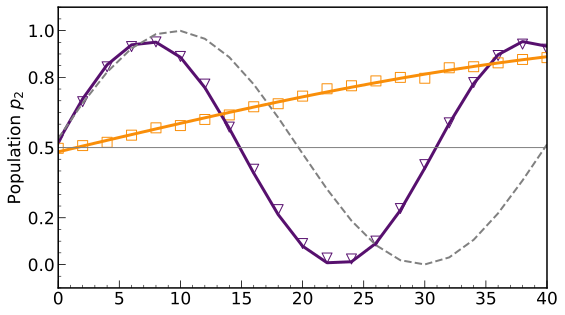

In [82]:
a1, p1 = sol_1.x
a6, p6 = sol_6.x
a2, p2 = sol_2.x

N_list = np.array([2*n for n in range(re_params[0]['N0'])])

# sim 1
pop2_sim1_ap = pop_sim(a1, p1)
a0=0.015
pop2_sim1_a = pop_sim(a1+a0, 0)

# sim 6
pop2_sim6_ap = pop_sim(a6, p6)

# sim 2
pop2_sim2_ap = pop_sim(a2, p2)

s0 = 100
lw0 = 3.0
fig, ax = plt.subplots(ncols=1, figsize=(8, 4.5))

ax.scatter(N_list, re_pops_2[0], facecolor='none', edgecolors='#57106e', s=s0, label='Un-corrected', marker='v')
ax.plot(N_list, pop2_sim1_ap[:, 1], color='#57106e', linewidth=lw0)
ax.plot(N_list, pop2_sim1_a[:, 1], color='grey', linewidth=2.0, linestyle='--')

ax.scatter(N_list, re_pops_2[5], facecolor='none', edgecolors='#f98e09', s=s0, label=r'Amplitude scaling', marker='s')
ax.plot(N_list, pop2_sim6_ap[:, 1], color='#f98e09', linewidth=lw0)

# ax.scatter(N_list, re_pops_1[2], facecolor='none', edgecolors=my_discrete[4], s=s0, label='DRAG $Y$-correction')
# ax.plot(N_list, pop2_sim2_ap[:, 1], color=my_discrete[4], linewidth=lw0)

# re_pops_subset = np.array([re_pops_2[2], re_pops_2[3], re_pops_2[4]])
# mean_re_pops = np.mean(re_pops_subset, axis=0)
# std_re_pops = np.std(re_pops_subset, axis=0)
ax.axhline(0.5, color='grey', linewidth=1.0)
# ax.plot(N_list, mean_re_pops, color=my_discrete[3], linewidth=0.5)
# ax.fill_between(N_list, mean_re_pops - std_re_pops, mean_re_pops + std_re_pops, color='grey', alpha=0.1)
# ax.scatter(N_list, mean_re_pops, facecolor=my_discrete[3], edgecolor='none', s=s0, marker='s', label='Both corrections')

ax.set_xlim([0, 40])
ax.set_yticks(np.round(np.linspace(0, 1.0, 5), 1))
ax.set_ylim([-0.1, 1.1])
ax.set_ylabel(r'Population $p_2$',fontsize=17)

ax.tick_params(axis='both', labelsize=17, direction='in', which='both')
ax.tick_params(axis='both', which='major', length=7.5)
ax.tick_params(axis='both', which='minor', length=3)
ax.minorticks_on()
fig.tight_layout()
# fig.savefig('fig1_re_a.png', dpi=300)

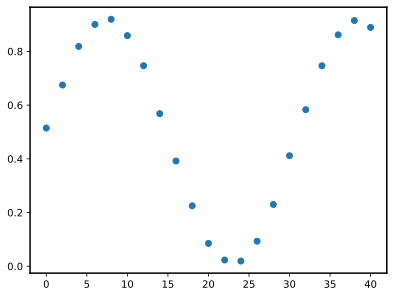

In [33]:
plt.scatter(N_list, re_pops_2[0])

In [ ]:
np.savez('./fig1_re.npz', N=N_list, pop2_uncorrected=re_pops_2[0],\
                
        )

In [34]:
N_list

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32,
       34, 36, 38, 40])

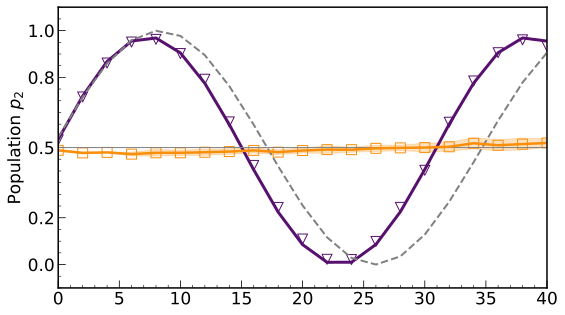

In [83]:
fig, ax = plt.subplots(ncols=1, figsize=(8, 4.5))

ax.scatter(N_list, re_pops_2[1], facecolor='none', edgecolors='#57106e', s=s0, label='DRAG $Y$-correction', marker='v')
ax.plot(N_list, pop2_sim2_ap[:, 1], color='#57106e', linewidth=lw0)
a0=0.012
pop2_sim2_a = pop_sim(a2+a0, 0)
ax.plot(N_list, pop2_sim2_a[:, 1], color='grey', linewidth=2.0, linestyle='--')

re_pops_subset = np.array([re_pops_2[2], re_pops_2[3], re_pops_2[4]])
mean_re_pops = np.mean(re_pops_subset, axis=0)
std_re_pops = np.std(re_pops_subset, axis=0)
ax.axhline(0.5, color='grey', linewidth=1.0)
ax.plot(N_list, mean_re_pops, color='#f98e09', linewidth=2.5)
ax.fill_between(N_list, mean_re_pops - std_re_pops, mean_re_pops + std_re_pops, color='#f98e09', alpha=0.25)
ax.scatter(N_list, mean_re_pops, facecolor='none', edgecolor='#f98e09', s=s0, marker='s', label='Both corrections')

ax.set_xlim([0, 40])
ax.set_yticks(np.round(np.linspace(0, 1.0, 5), 1))
ax.set_ylim([-0.1, 1.1])
ax.set_ylabel(r'Population $p_2$',fontsize=17)


ax.tick_params(axis='both', labelsize=17, direction='in', which='both')
ax.tick_params(axis='both', which='major', length=7.5)
ax.tick_params(axis='both', which='minor', length=3)
ax.minorticks_on()
fig.tight_layout()
# fig.savefig('fig1_re_b.png', dpi=300)

# Figure 2. APE

In [126]:
ape_ids = ['cw0sjvk79ws0008z27j0', 'cw0t1qe4v2e0008sfxeg', 'cw0twskjz3x0008j6xx0', 'cw0v84079ws0008z2as0']
paths = [f"./calibrator/phase_error1/data/{id}" for id in ape_ids]
pe_iq_datas = [np.array(np.load(f"{p}/iq_data.pkl", allow_pickle=True)) for p in paths]
pe_params = [np.array(np.load(f"{p}/params.pkl", allow_pickle=True)) for p in paths]

In [127]:
pe_params

[array({'pe_job_id_string': 'cw0sjvk79ws0008z27j0', 'datetime': datetime.datetime(2024, 10, 5, 21, 54, 33, 953509), 'duration': 40, 'amp': 0.2513636363636364, 'optimized_beta': 0, 'num_points': 150, 'num_shots': 5000, 'rep_range': [1, 3], 'delay_overlap': True, 'mapping_01': True, 'rep_delay': '0.0005', 'extended_delay': '0.0', 'idling_circuits': False, 'unconditional_reset12': True},
       dtype=object),
 array({'pe_job_id_string': 'cw0t1qe4v2e0008sfxeg', 'datetime': datetime.datetime(2024, 10, 5, 22, 26, 10, 66884), 'duration': 40, 'amp': 0.2513636363636364, 'optimized_beta': 0, 'num_points': 150, 'num_shots': 5000, 'rep_range': [5, 7], 'delay_overlap': True, 'mapping_01': True, 'rep_delay': '0.0005', 'extended_delay': '0.0', 'idling_circuits': False, 'unconditional_reset12': True},
       dtype=object),
 array({'pe_job_id_string': 'cw0twskjz3x0008j6xx0', 'datetime': datetime.datetime(2024, 10, 5, 23, 23, 56, 41583), 'duration': 40, 'amp': 0.2513636363636364, 'optimized_beta': -0.41

In [128]:
angle_swept = np.linspace(-np.pi/6, -np.pi/6 + 2 * np.pi, 75)

pe_pops = []

for iq_data in pe_iq_datas:
    _, _, pe_pop = discriminate(iq_data)
    pe_pops.append(pe_pop)
pe_pops = np.array(pe_pops)

In [129]:
pe_pops.shape

(4, 150, 3)

In [132]:
pe_pops = np.reshape(pe_pops, (8, 75, 3))

In [133]:
def ape_plus(a, p):
    return (-1j*((np.pi/2+a)/2)*Lx12()-1j*(p/2)*Lz12()).expm() 

def ape_minus(a, p):
    return (-1j*((-np.pi/2-a)/2)*Lx12()-1j*(p/2)*Lz12()).expm() 

def obj_ape(args):

    a, p = args
    pop1_sim = []
    for angle in angle_swept:
        psi0 = ket1 
        psi0 = ape_plus(a, p)*psi0
        for j in range(rep):
            psi0 = ape_minus(-a, p)*ape_plus(a, p)*psi0 
        psi0 = R12(-np.pi/2-a, angle)*psi0
        pop1 = (np.abs(ket1.dag()*psi0))**2
        pop1_sim.append(pop1)

    pop1_sim = np.array(pop1_sim)
    pop_dif = np.abs(pop1_sim - pop1_exp)**2
    print(np.average(pop_dif))

    return np.average(pop_dif)


def pop_sim_ape(a, p, rep):
    pop1_sim = []
    for angle in angle_swept:
        psi0 = ket1 
        psi0 = ape_plus(a, p)*psi0
        for j in range(rep):
            psi0 = ape_minus(-a, p)*ape_plus(a, p)*psi0 
        psi0 = R12(-np.pi/2-a, angle)*psi0
        pop1 = (np.abs(ket1.dag()*psi0))**2
        pop1_sim.append(pop1)

    pop1_sim = np.array(pop1_sim)
    return pop1_sim

guess_ape = [5e-2, 5e-2]
idx = 0
solutions_ape = []
for rep in [1, 3, 5, 7]:
    pop1_exp = pe_pops[idx][:, 0]
    sol_ape = minimize(obj_ape, guess_ape, method='Nelder-Mead', tol=1e-9)
    idx += 1
    solutions_ape.append(sol_ape)

0.00016224401392312082
0.00015784844878275205
0.00016267564940404983
0.0001623830042174065
0.00016054842330268012
0.0001566610746537923
0.00015513032730215994
0.00015197345131694564
0.00014893443861330644
0.00015089941074895838
0.0001478044612240841
0.00015207359193941526
0.0001457713498297926
0.00014657689185107394
0.00014836913505680661
0.00014647535418471112
0.0001458065696855103
0.0001495252356232128
0.00014543339974779453
0.00014638916486442937
0.00014547761122062877
0.0001455140235114667
0.00014536207319898378
0.00014590213846108797
0.00014535146063851252
0.00014542678672826341
0.00014536142586430166
0.00014543891213433875
0.00014534324893552517
0.0001453525959231549
0.0001453433744359312
0.00014535266710940977
0.00014534299255593457
0.00014534701166246626
0.00014534089894255105
0.00014535528407621116
0.0001453405526144442
0.00014534143080913487
0.00014534047127159143
0.0001453423805970211
0.00014534037505754547
0.00014534054592262635
0.00014534038419295803
0.00014534070439993106

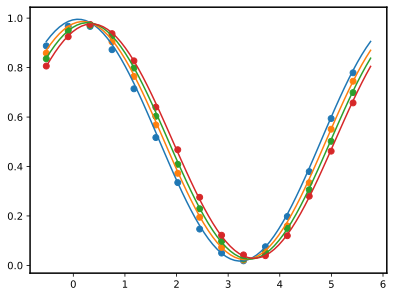

In [134]:
rep_range = [1, 3, 5, 7]
for i in range(4):
    plt.scatter(angle_swept[::5], pe_pops[i][:, 0][::5])
    plt.plot(angle_swept, pop_sim_ape(solutions_ape[i].x[0], solutions_ape[i].x[1], rep=rep_range[i]))

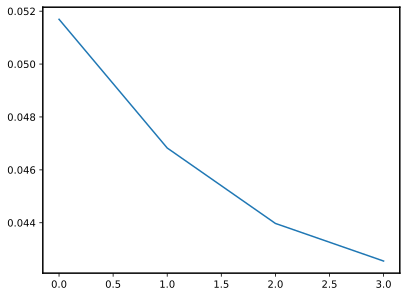

In [136]:
plt.plot([0.05169382617458747, 0.04682551356577483, 0.043973255965181625, 0.042550758768561014])

In [258]:
delta_fit_using_eqn1 = np.array([0.05169382617458747, 0.04682551356577483, 0.043973255965181625, 0.042550758768561014])

np.mean(delta_fit_using_eqn1), np.std(delta_fit_using_eqn1)

(0.046260838618526236, 0.0034940641976560593)

In [259]:
0.34*1e-2

0.0034000000000000002

In [137]:
pe_fits = []
init_phases = []

for pop in pe_pops:
    pop = pop[:, 0]
    popt, yfit, pcov = ut.fit_function(angle_swept, 
                                    pop, 
                                    lambda x, A, B, phi: (A*np.cos(x+phi)+B), 
                                    [0.5, 0, 0])
    pe_fits.append(yfit)
    init_phases.append(popt[-1])

/var/folders/z6/rm3bbyf1499dhyn1b2tcy4s80000gn/T/ipykernel_18642/3704838655.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  inferno_cmap = cm.get_cmap('inferno')  # Get the full inferno colormap


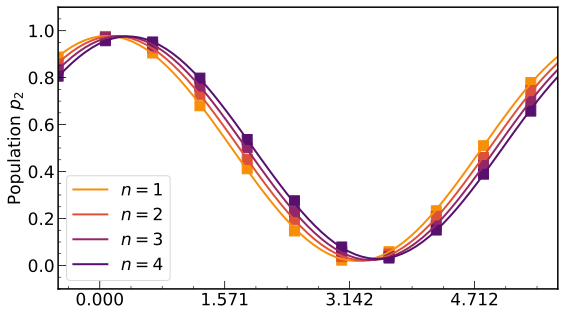

In [303]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm

fig, axes = plt.subplots(nrows=1, figsize=(8, 4.5))

# Define the custom colormap as a subset of inferno
inferno_cmap = cm.get_cmap('inferno')  # Get the full inferno colormap
custom_cmap = LinearSegmentedColormap.from_list("custom_inferno", [inferno_cmap(0.88), inferno_cmap(0.25)])  # Subset

# Sample 4 colors from the gradient
my_discrete = ['#f98e09', '#dd513a', '#932667', '#57106e']

skip_point_1 = 7
skip_point_2 = 4

lw0 = 2.0
for idx in range(4):
    clr = my_discrete[idx]
    axes.scatter(angle_swept[::skip_point_1], pe_pops[idx][:, 0][::skip_point_1], color=clr, marker='s', s=s0)
    axes.plot(angle_swept, pe_fits[idx], color=clr, linewidth=lw0, label=rf'$n={idx+1}$')
    # axes[0, 1].scatter(angle_swept[::skip_point_2], pe_pops[idx][:, 0][::skip_point_2], color=clr, marker='s')
    # axes[0, 1].plot(angle_swept, pe_fits[idx], color=clr)

axes.set_xlim([min(angle_swept), max(angle_swept)])
# axes[0, 1].set_xlim([np.pi-np.pi/5, np.pi+np.pi/5])
axes.set_ylim([-0.1, 1.1])
axes.legend(fontsize=17)
# axes[0, 1].set_ylim([0, 0.2])

# for idx in range(4):
#     jdx = idx+4
#     clr = my_discrete[idx]
#     axes[1].scatter(angle_swept[::skip_point_1], pe_pops[jdx][:, 0][::skip_point_1], color=clr, marker='s', s=s0)
#     axes[1].plot(angle_swept, pe_fits[jdx], color=clr, linewidth=lw0)
#     axes[1].plot(angle_swept, pe_fits[idx], color='grey', linewidth=0.25)
#     # axes[1, 1].scatter(angle_swept[::skip_point_2], pe_pops[jdx][:, 0][::skip_point_2], color=clr, marker='s')
#     # axes[1, 1].plot(angle_swept, pe_fits[jdx], color=clr)
#     # axes[1, 1].plot(angle_swept, pe_fits[idx], color='grey', linewidth=0.25)

# axes[1].set_xlim([min(angle_swept), max(angle_swept)])
# # axes[1, 1].set_xlim([np.pi-np.pi/5, np.pi+np.pi/5])
# axes[1].set_ylim([0, 1.0])
# # axes[1, 1].set_ylim([0, 0.2])

my_xticks = [0, np.pi/2, np.pi, 3*np.pi/2]
axes.set_xticks(my_xticks)

axes.tick_params(axis='both', labelsize=17, direction='in', which='both')
axes.minorticks_on()
axes.tick_params(axis='both', which='major', length=8)
axes.tick_params(axis='both', which='minor', length=3)

axes.set_ylabel(r'Population $p_2$', fontsize=17)

fig.tight_layout()
fig.savefig('fig2_ape_1.png',dpi=300)

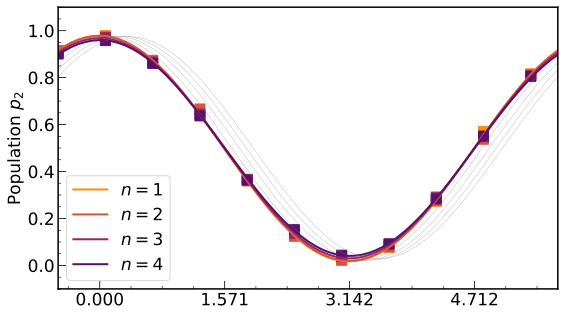

In [304]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm

fig, axes = plt.subplots(nrows=1, figsize=(8, 4.5))


skip_point_1 = 7
skip_point_2 = 4
# for idx in range(4):
#     clr = my_discrete[idx]
#     axes.scatter(angle_swept[::skip_point_1], pe_pops[idx][:, 0][::skip_point_1], color=clr, marker='s', s=s0)
#     axes.plot(angle_swept, pe_fits[idx], color=clr, linewidth=lw0)
#     # axes[0, 1].scatter(angle_swept[::skip_point_2], pe_pops[idx][:, 0][::skip_point_2], color=clr, marker='s')
#     # axes[0, 1].plot(angle_swept, pe_fits[idx], color=clr)

# axes.set_xlim([min(angle_swept), max(angle_swept)])
# # axes[0, 1].set_xlim([np.pi-np.pi/5, np.pi+np.pi/5])
# axes.set_ylim([0, 1.0])
# # axes[0, 1].set_ylim([0, 0.2])

for idx in range(4):
    jdx = idx+4
    clr = my_discrete[idx]
    axes.scatter(angle_swept[::skip_point_1], pe_pops[jdx][:, 0][::skip_point_1], color=clr, marker='s', s=s0)
    axes.plot(angle_swept, pe_fits[jdx], color=clr, linewidth=lw0, label=rf'$n={idx+1}$')
    axes.plot(angle_swept, pe_fits[idx], color='grey', linewidth=0.25)
    # axes[1, 1].scatter(angle_swept[::skip_point_2], pe_pops[jdx][:, 0][::skip_point_2], color=clr, marker='s')
    # axes[1, 1].plot(angle_swept, pe_fits[jdx], color=clr)
    # axes[1, 1].plot(angle_swept, pe_fits[idx], color='grey', linewidth=0.25)
axes.legend(fontsize=17)
axes.set_xlim([min(angle_swept), max(angle_swept)])
# axes[1, 1].set_xlim([np.pi-np.pi/5, np.pi+np.pi/5])
axes.set_ylim([-0.1, 1.1])
# axes[1, 1].set_ylim([0, 0.2])


my_xticks = [0, np.pi/2, np.pi, 3*np.pi/2]
axes.set_xticks(my_xticks)


axes.tick_params(axis='both', labelsize=17, direction='in', which='both')
axes.minorticks_on()
axes.tick_params(axis='both', which='major', length=8)
axes.tick_params(axis='both', which='minor', length=3)

axes.set_ylabel(r'Population $p_2$', fontsize=17)

fig.tight_layout()
fig.savefig('fig2_ape_2.png',dpi=300)

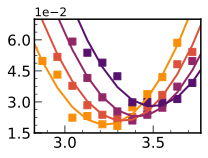

In [305]:
fig, ax = plt.subplots(figsize=(3, 2.3))
skip_point_3 = 1
for idx in range(4):
    clr = my_discrete[idx]
    ax.scatter(angle_swept[::skip_point_3], pe_pops[idx][:, 0][::skip_point_3], color=clr, marker='s', s=50)
    ax.plot(angle_swept, pe_fits[idx], color=clr, linewidth=lw0)

ax.set_xlim([np.pi-np.pi/10, np.pi+np.pi/5])
ax.set_ylim([0.015, 0.07])
ax.tick_params(axis='both', labelsize=15, direction='in', which='both')
ax.minorticks_on()
ax.tick_params(axis='both', which='major', length=7.5)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_yticks(np.arange(0.015, 0.07, 0.015))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.yaxis.offsetText.set_fontsize(12)

fig.tight_layout()
fig.savefig('fig2_ape_inset1.png', dpi=300, transparent=True)

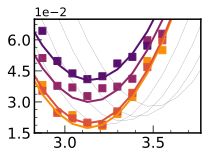

In [306]:
fig, ax = plt.subplots(figsize=(3, 2.3))
skip_point_3 = 1
for idx in range(4):
    jdx = idx+4
    clr = my_discrete[idx]
    ax.scatter(angle_swept[::skip_point_3], pe_pops[jdx][:, 0][::skip_point_3], color=clr, marker='s', s=50)
    ax.plot(angle_swept, pe_fits[jdx], color=clr, linewidth=lw0)
    ax.plot(angle_swept, pe_fits[idx], color='grey', linewidth=0.25)

ax.set_xlim([np.pi-np.pi/10, np.pi+np.pi/5])
ax.set_ylim([0.015, 0.07])
ax.tick_params(axis='both', labelsize=15, direction='in', which='both')
ax.minorticks_on()
ax.tick_params(axis='both', which='major', length=7.5)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_yticks(np.arange(0.015, 0.07, 0.015))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.yaxis.offsetText.set_fontsize(12)
fig.tight_layout()
fig.savefig('fig2_ape_inset2.png', dpi=300, transparent=True)

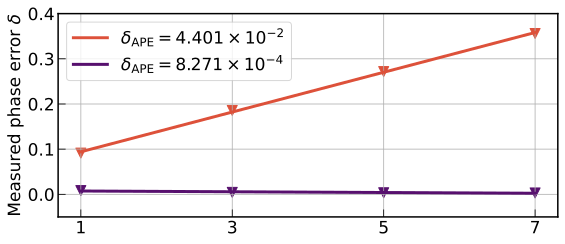

In [297]:
fig, axes = plt.subplots(figsize=(8, 3.5))

# Fit functions for linear fitting on each dataset
poplin1, linearfit1, _ = ut.fit_function(np.array([1, 3, 5, 7]), 
                                np.abs(init_phases[:4]), 
                                lambda x, A, B: (A * x + B), 
                                [0.5, 0.1])

poplin2, linearfit2, _ = ut.fit_function(np.array([1, 3, 5, 7]), 
                                np.abs(init_phases[4:]), 
                                lambda x, A, B: (A * x + B), 
                                [0, 0])

# Scatter and plot for the first set of data
plt.scatter([1, 3, 5, 7], np.abs(init_phases[:4]), s=s0, marker='v', color=my_discrete[1])
plt.plot([1, 3, 5, 7], linearfit1, color=my_discrete[1], label=r'$\delta_{\text{APE}}=4.401\times 10^{-2}$', linewidth=lw0)

# Scatter and plot for the second set of data
plt.scatter([1, 3, 5, 7], np.abs(init_phases[4:]), s=s0, marker='v', color=my_discrete[3])
plt.plot([1, 3, 5, 7], linearfit2, color=my_discrete[3], label=r'$\delta_{\text{APE}}=8.271\times 10^{-4}$', linewidth=lw0)

# # Set label and tick positions
# axes.xaxis.set_label_position('top')
# axes.xaxis.set_ticks_position('top')
# axes.yaxis.set_label_position('right')
# axes.yaxis.set_ticks_position('right')

# Grid and tick settings, with tick labels inside
# axes.tick_params(axis='x', labelsize=15, direction='in', labeltop=True, pad=-25)
# axes.tick_params(axis='y', labelsize=15, direction='in', labelright=True, pad=-35)
axes.tick_params(axis='both', which='major', length=7.5)
axes.tick_params(axis='both', which='minor', length=3)
axes.set_yticks(np.round(np.linspace(0, 0.4, 5), 1))
axes.set_xticks(np.round(np.linspace(1, 7, 4), 1))
axes.set_ylim(-0.05, 0.4)

# Legend on top of the plot
axes.legend(fontsize=17)
axes.tick_params(axis='both', labelsize=17, direction='in', which='both')
axes.set_ylabel('Measured phase error $\delta$', fontsize=17)
axes.grid()
# Save figure
fig.tight_layout()
fig.savefig('fig2_ape_inset.png', dpi=300, transparent=True)

In [298]:
poplin1, poplin2

(array([0.04401724, 0.05014399]), array([-0.00082709,  0.00817537]))

In [299]:
8.271*1e-4

0.0008271000000000001

# Fig 2. DRAPE

In [300]:
drape1_id = 'cwhsrpt0r6b0008pqb90'
drape2_id = 'cwhvkgy543p00086em8g'

exp_ids = [drape1_id, drape2_id]

paths = []
for id in exp_ids:
    paths.append(f"./calibrator/drag/data/{id}")

ad_iq_datas = []
ad_params = []
drape_pops = []

for path in paths:
    ad_iq_datas.append(np.array(np.load(f"{path}/iq_data.pkl", allow_pickle=True)))
    ad_params.append(np.load(f"{path}/params.pkl", allow_pickle=True))

for iq_data in ad_iq_datas:
    _, _, drape_pop = discriminate(iq_data)
    drape_pops.append(drape_pop)

drape_pops = np.array(drape_pops)

In [301]:
drape_pops = np.reshape(drape_pops, (6, 50, 3))
beta_swept = np.linspace(ad_params[0]['beta_min'], ad_params[0]['beta_max'], ad_params[0]['num_betas'])

for i in range(drape_pops.shape[0]): 
    if i > 2:
        drape_pops[i][:, 2] += 0.015

y_fit_pops = []
popt_pops = []

for pop in drape_pops:
    popt, yfit, pcov = ut.fit_function(beta_swept, 
                                    pop[:, 2], 
                                    lambda x, A, B: (A*x+B), 
                                    [-0.5, 0])
    y_fit_pops.append(yfit)
    popt_pops.append(popt)

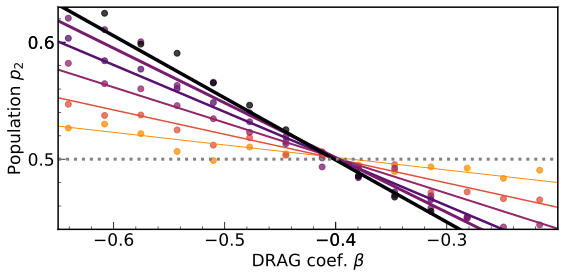

In [312]:
fig, ax = plt.subplots(figsize=(8, 4))
my_discrete = ['#f98e09', '#dd513a', '#932667', '#57106e', '#781c6d', '#000004']
j = 1.0
for i in range(drape_pops.shape[0]): 
    ax.scatter(beta_swept[::2], drape_pops[i][:, 2][::2], alpha=0.75, color=my_discrete[i])
    ax.plot(beta_swept, y_fit_pops[i], label=f'{i}', linewidth=j, color=my_discrete[i])
    j+=0.5

ax.axhline(0.5, linewidth=3.0, linestyle='dotted', color='grey')

ax.tick_params(axis='both', labelsize=17, direction='in', which='both')
ax.minorticks_on()
ax.tick_params(axis='both', which='major', length=7.5)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_xticks(np.round(np.linspace(-0.60, -0.3, 5), 1))
ax.set_yticks(np.round(np.linspace(0.45, 0.60, 4), 1))
ax.set_ylim([0.44, 0.63])
ax.set_xlim([-0.65, -0.2])
ax.set_ylabel(r'Population $p_2$', fontsize=17)
ax.set_xlabel(r'DRAG coef. $\beta$', fontsize=17)

fig.tight_layout()
fig.savefig('drape.png',dpi=300, transparent=True)